Note Book de Jean-Olivier

In [74]:
import pandas as pd
import sqlite3

# Dans le fichier BRUT, il y a 4,271 lignes. On a nettoyé ce fichier.
# Dans le fichier CLEAN, il y a 4,145 lignes.
filepath = "../data/allergies_clean.csv"
db_path = "../data/allergen_chip_challenge.db"

# Si on veut, on peut lire à partir du fichier CSV, ou lire à partir de la base SQLite
#df = pd.read_csv(filepath_or_buffer=filepath)

conn = sqlite3.connect(db_path)

df = pd.read_sql("Select * From allergies", conn)
conn.close()

df.shape

(4145, 255)

In [75]:
df.iloc[:, 0:10].head()

,Patient_ID,Chip_Type,Age,Gender,Blood_Month_sample,Region,Urban_area,Sensitization,Treatment_of_rhinitis,Treatment_of_asthma
0,FHB0001,ISAC_V1,20 à 40,1,11.0,regionB,0,1,Non renseigné,0
1,FHB0002,ISAC_V1,40 à 60,0,12.0,regionB,0,1,Non renseigné,0
2,FHB0003,ISAC_V1,0 à 20,1,1.0,regionB,0,0,Anti-H1 voie générale,0
3,FHB0004,ISAC_V1,0 à 20,0,1.0,regionB,0,1,Non renseigné,0
4,FHB0005,ISAC_V1,20 à 40,0,1.0,regionB,0,1,Non renseigné,0


In [76]:
df["Urban_area"].value_counts()

Urban_area
0    3179
1     966
Name: count, dtype: int64

In [77]:
df["Treatment_of_rhinitis"].value_counts()

Treatment_of_rhinitis
Non renseigné            2832
Aucun                     883
Anti-H1 voie générale     223
Anti-H1 + CS              115
Anti-H1, voie locale       92
Name: count, dtype: int64

In [78]:
df.iloc[:, 10:20].head()

,Age_of_onsets,Skin_Symptoms,General_cofactors,Treatment_of_atopic_dematitis,Act_d_1,Act_d_2,Act_d_5,Act_d_8,Aln_g_1,Alt_a_1
0,Non renseigné,0,Aucun,Non renseigné,0.0,0.0,0.0,0.0,0.00,0.0
1,Non renseigné,0,Aucun,Non renseigné,0.0,0.0,0.0,6.0,19.32,0.0
2,Aucun,0,Acariens,Non renseigné,0.0,0.0,0.0,0.0,0.00,0.0
3,Non renseigné,0,Aucun,Non renseigné,0.0,0.0,0.0,0.0,13.42,0.0
4,Non renseigné,0,Aucun,Non renseigné,0.0,0.0,0.0,0.0,0.00,0.0


In [79]:
df["Treatment_of_asthma"].value_counts()

Treatment_of_asthma
0    3542
1     603
Name: count, dtype: int64

In [80]:
df["Age_of_onsets"].value_counts()

Age_of_onsets
Non renseigné     2446
Aucun              622
0 - 2 ans          350
3 - 10 ans         296
20 ans et plus     150
10 - 20 ans        147
2 - 3 ans          134
Name: count, dtype: int64

In [81]:
df["Skin_Symptoms"].value_counts()

Skin_Symptoms
0    3005
1    1140
Name: count, dtype: int64

In [82]:
df["General_cofactors"].value_counts()

General_cofactors
Aucun                       3009
Animaux : cheval/rongeur     794
Effort/Activité sportive     141
Animaux : chat/chien          87
Acariens                      57
Moisissures                   36
Autres                        21
Name: count, dtype: int64

In [83]:
df["Treatment_of_atopic_dematitis"].value_counts()

Treatment_of_atopic_dematitis
Non renseigné        2563
Pas de traitement    1294
Dermocorticoïdes      122
Dupilumab              84
Autres                 82
Name: count, dtype: int64

In [84]:
df.iloc[:, 20:30].head()

,Alt_a_6,Amb_a_1,Ana_o_2,Ani_s_1,Ani_s_3,Api_g_1,Api_m_1,Api_m_4,Ara_h_1,Ara_h_2
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [85]:
df.shape

(4145, 255)

In [86]:
df2 = df.drop_duplicates()

df2.shape

(4145, 255)

In [87]:
# Choix parmi 241 colonnes de réactifs d'allergènes. Les corrélations avec la colonne globale de sensibilité permet d'isoler les meilleurs indicateurs.

corr_sensitization = []
best_corr_sensitization = []
best_columns = []
all_cols = df2.columns

for i in range(14, len(all_cols)):
    col = all_cols[i]
    c = df2[["Sensitization", col]].corr()
    value = float(c.iloc[0, 1])
    cval = value, col
    corr_sensitization.append(cval)
    # Seuil à 0.1
    if value>=0.1:
        best_corr_sensitization.append(cval)
        best_columns.append(col)

corr_sensitization.sort(reverse=True)
best_corr_sensitization.sort(reverse=True)

best_corr_sensitization

[(0.1914861355745523, 'Phl_p_1'),
 (0.18799315902329816, 'Der_f_2'),
 (0.18312291400122632, 'Der_p_2'),
 (0.16531053541046256, 'Der_p_1'),
 (0.16110494552900706, 'Der_f_1'),
 (0.1608184481558884, 'Fel_d_1'),
 (0.15923882605423964, 'Bet_v_1'),
 (0.14178266899807548, 'Cup_a_1'),
 (0.13186219033673835, 'Ole_e_1'),
 (0.1317138782166565, 'Cyn_d_1'),
 (0.12598058665016984, 'Phl_p_5'),
 (0.12413674923742744, 'Phl_p_2'),
 (0.12156431988320894, 'Cor_a_1.0401'),
 (0.11652962523656299, 'Mal_d_1'),
 (0.114660236982941, 'Cry_j_1'),
 (0.11300755091406729, 'Alt_a_1'),
 (0.1076937387129692, 'Phl_p_4'),
 (0.10761203641969452, 'Aln_g_1'),
 (0.10328696311313916, 'Phl_p_6'),
 (0.10244969207815462, 'Ara_h_6')]

In [88]:
# On force l'ajout du lait de vache, et du chien parmi les colonnes explicatives :
best_columns.append("Bos_d_8")
best_columns.append("Can_f_1")

# On enlève Der_p_1, Der_p_2 (car il est très similaire aux autres colonnes des acariens, Der_f_1, Der_f_2 est le gène majeur) :
if "Der_p_1" in best_columns:
    best_columns.remove("Der_p_1")
if "Der_p_2" in best_columns:
    best_columns.remove("Der_p_2")
# On enlève aussi Cor_a_1.0401 (la colonne entraîne de la colinéarité avec plusieurs colonnes)
if "Cor_a_1.0401" in best_columns:
    best_columns.remove("Cor_a_1.0401")

# On veut être sûr qu'il n'y a pas de doublons :
best_columns = list(set(best_columns))

len(best_columns)

19

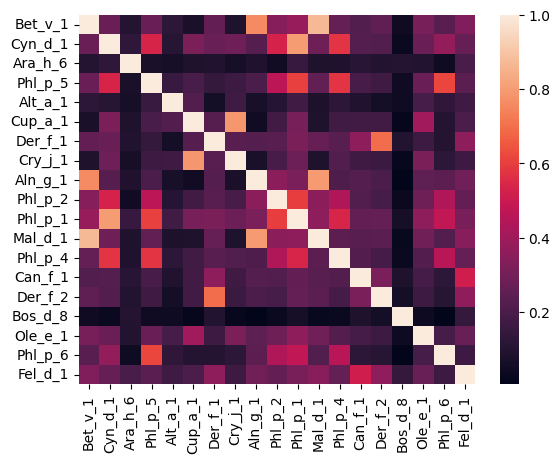

In [89]:
import seaborn as sns
from matplotlib import pyplot as plt

corr_df = df2[best_columns].corr()


# Doit-on ajouter des colonnes intéressantes ?
# Lait de vache ==> Bos_d_8
# Chien         ==> Can_f_1


sns.heatmap(corr_df)
plt.show()

In [90]:
left_columns = []

# Taking columns from the left hand, but not the row-id neither the Patient_ID:
for i in range(1, 14):
    left_columns.append(all_cols[i])

left_columns

['Chip_Type',
 'Age',
 'Gender',
 'Blood_Month_sample',
 'Region',
 'Urban_area',
 'Sensitization',
 'Treatment_of_rhinitis',
 'Treatment_of_asthma',
 'Age_of_onsets',
 'Skin_Symptoms',
 'General_cofactors',
 'Treatment_of_atopic_dematitis']

In [91]:
columns_to_keep = left_columns + best_columns

print(f"We will keep {len(columns_to_keep)} columns, as they seem interesting")

We will keep 32 columns, as they seem interesting


In [92]:
col_that_need_dummies = ['Chip_Type', 'Age', 'Blood_Month_sample', 'Region', 'Treatment_of_rhinitis', 'Age_of_onsets', 'General_cofactors', 'Treatment_of_atopic_dematitis']

# We keep only the columns to keep, and (for the pure categorical columns) we make some dummies.
df2 = df2[columns_to_keep]
df3 = pd.get_dummies(data=df2, columns=col_that_need_dummies)

df3.shape


(4145, 82)

In [93]:
df3.head()

,Gender,Urban_area,Sensitization,Treatment_of_asthma,Skin_Symptoms,Bet_v_1,Cyn_d_1,Ara_h_6,Phl_p_5,Alt_a_1,...,General_cofactors_Animaux : cheval/rongeur,General_cofactors_Aucun,General_cofactors_Autres,General_cofactors_Effort/Activité sportive,General_cofactors_Moisissures,Treatment_of_atopic_dematitis_Autres,Treatment_of_atopic_dematitis_Dermocorticoïdes,Treatment_of_atopic_dematitis_Dupilumab,Treatment_of_atopic_dematitis_Non renseigné,Treatment_of_atopic_dematitis_Pas de traitement
0,1,0,1,0,0,0.00,0.00,0.0,0.00,0.0,...,False,True,False,False,False,False,False,False,True,False
1,0,0,1,0,0,85.74,0.00,0.0,0.00,0.0,...,False,True,False,False,False,False,False,False,True,False
2,1,0,0,0,0,0.00,0.00,0.0,0.00,0.0,...,False,False,False,False,False,False,False,False,True,False
3,0,0,1,0,0,41.95,46.86,0.0,51.02,0.0,...,False,True,False,False,False,False,False,False,True,False
4,0,0,1,0,0,0.00,50.83,0.0,48.00,0.0,...,False,True,False,False,False,False,False,False,True,False


In [94]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

# Both models are SCORING at 0.92, but what will it be if we remove Urban_area column?
# Removing Urban_area column changes nothing to the SCORE.

X = df3.drop(columns=["Sensitization"])
y = df3["Sensitization"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

lr.fit(X=X_train, y=y_train)

score = lr.score(X=X_test, y=y_test)

print(score)

0.9218900675024108


In [95]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()

rfc.fit(X=X_train, y=y_train)

score = rfc.score(X=X_test, y=y_test)

print(score)

0.9189971070395371


In [104]:
nb_pathologiques = y_test.sum()
y_est = rfc.predict(X_test)
nb_pathologiques_pred = y_est.sum()

total_obs = len(y_test)

true_positive = (y_est==1) & (y_test==1)
nb_true_positive = true_positive.sum()

print(f"nb_pathologiques={nb_pathologiques}, nb_pathologiques_pred={nb_pathologiques_pred}, total_obs={total_obs}")

# Précision : ensemble des vrais positifs / ensemble des prédictions positives
PRECISION = nb_true_positive / nb_pathologiques_pred
naive_precision = nb_pathologiques / len(y_test)
print(f"PRECISION = {PRECISION}, NAIVE-PRECISION = {naive_precision}")

# Recall : ensemble des vrais positifs / ensemble des positifs réels
RECALL = nb_true_positive / nb_pathologiques
print(f"RECALL = {RECALL}")

F1_Score = 2 * (PRECISION*RECALL) / (PRECISION+RECALL)
print(f"F1_Score = {F1_Score}")

nb_pathologiques=856, nb_pathologiques_pred=856, total_obs=1037
PRECISION = 0.9509345794392523, NAIVE-PRECISION = 0.8254580520732884
RECALL = 0.9509345794392523
F1_Score = 0.9509345794392523


In [97]:
allergens_df = pd.read_csv("../data/allergens.csv")

allergens_df.head()

,allergen,name,molecular_mass,route
0,Aca f 1,Ole e 1-like protein,17 kDa,Airway
1,Aca f 2,Profilin,14.3 kDa,Airway
2,Aca s 13,Cytosolic fatty acid-binding protein,15 kDa,Airway
3,Aca s 2,NPC2 family; MD-2-related lipid recognition (M...,14 kDa,Airway
4,Act c 10,Non-specific lipid transfer protein type 1 (ns...,10 kDa,Food


In [98]:
dico = {}
for i in range(len(allergens_df)):
    dico[allergens_df.iloc[i, 0].strip()] = f"{allergens_df.iloc[i, 1]} / {allergens_df.iloc[i, 3]}"

len(allergens_df)

1155

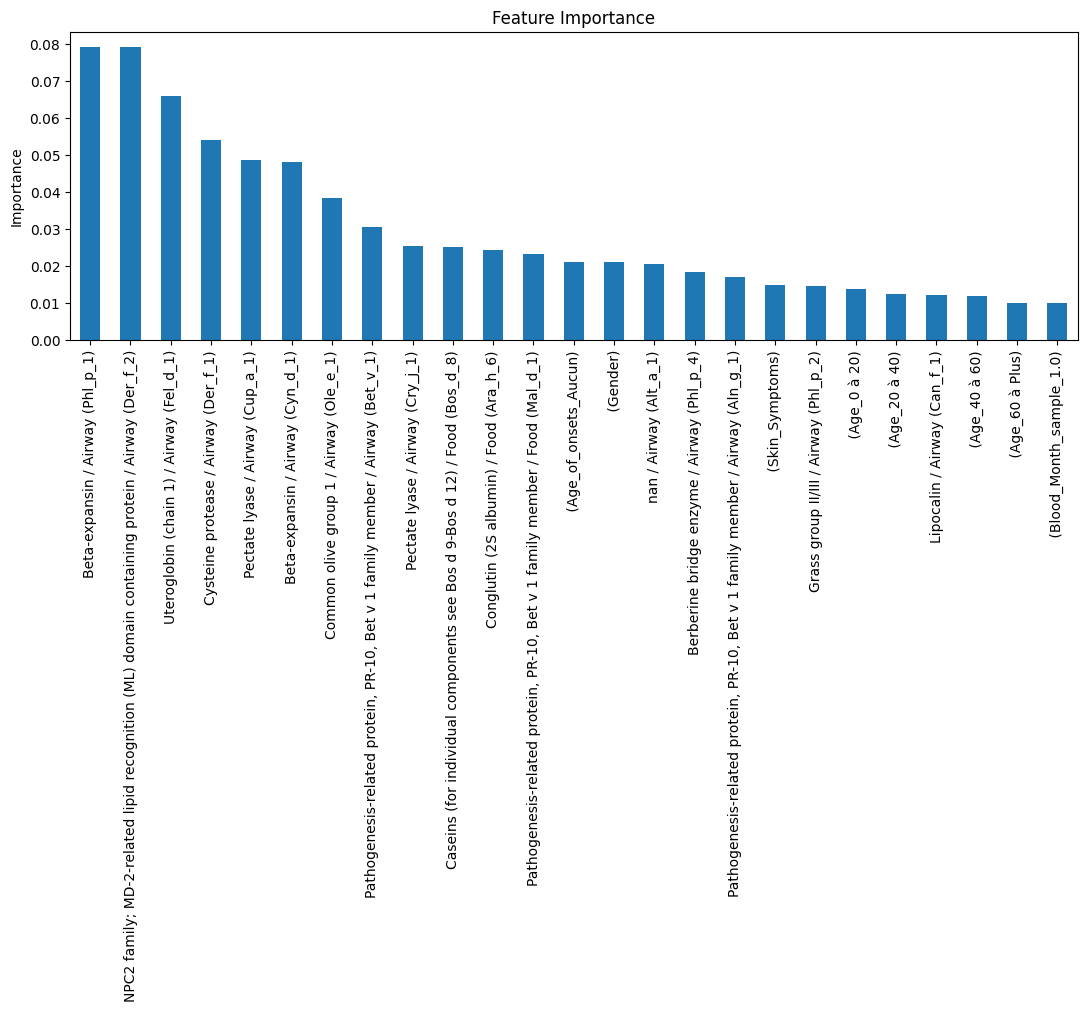

In [99]:
import matplotlib.pyplot as plt

# Get feature importances
index_labels = [f"{dico.get(z.replace('_', ' '), '')} ({z})" for z in X_train.columns]

importances = pd.Series(rfc.feature_importances_, index=index_labels)
importances = importances.sort_values(ascending=False)

# Top 25
importances_z = importances[:25]

# Plot
plt.figure(figsize=(13, 4))
importances_z.plot(kind='bar')
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()

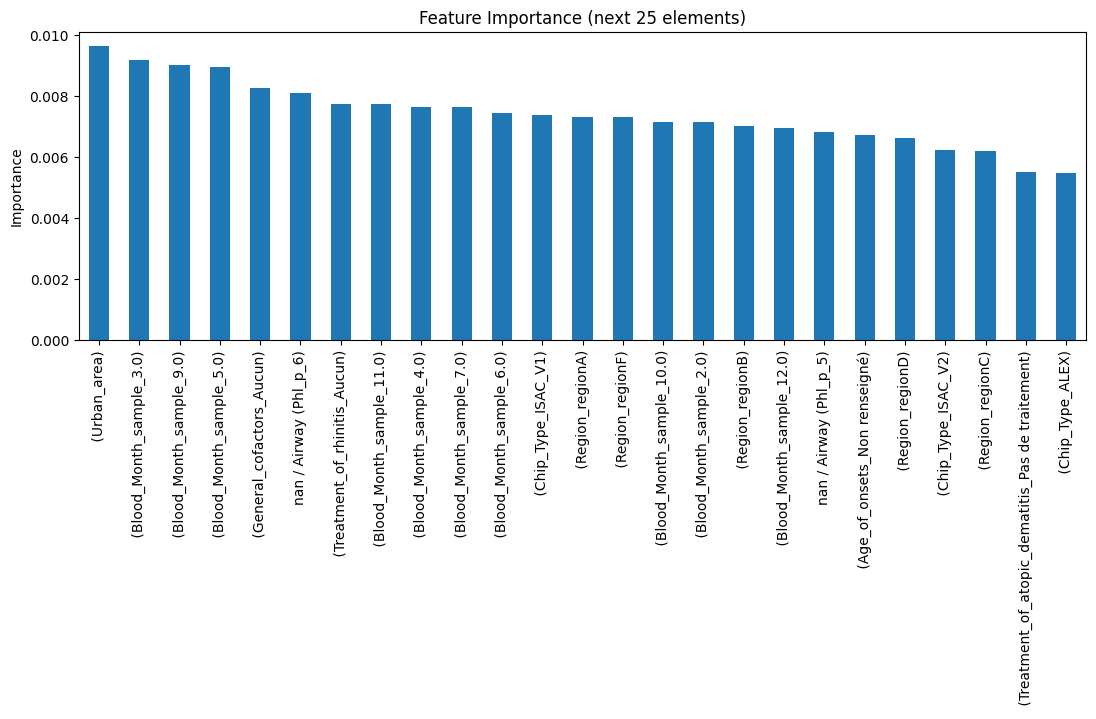

In [100]:
# Top 25 - next
importances_z = importances[25:50]

# Plot
plt.figure(figsize=(13, 4))
importances_z.plot(kind='bar')
plt.title("Feature Importance (next 25 elements)")
plt.ylabel("Importance")
plt.show()

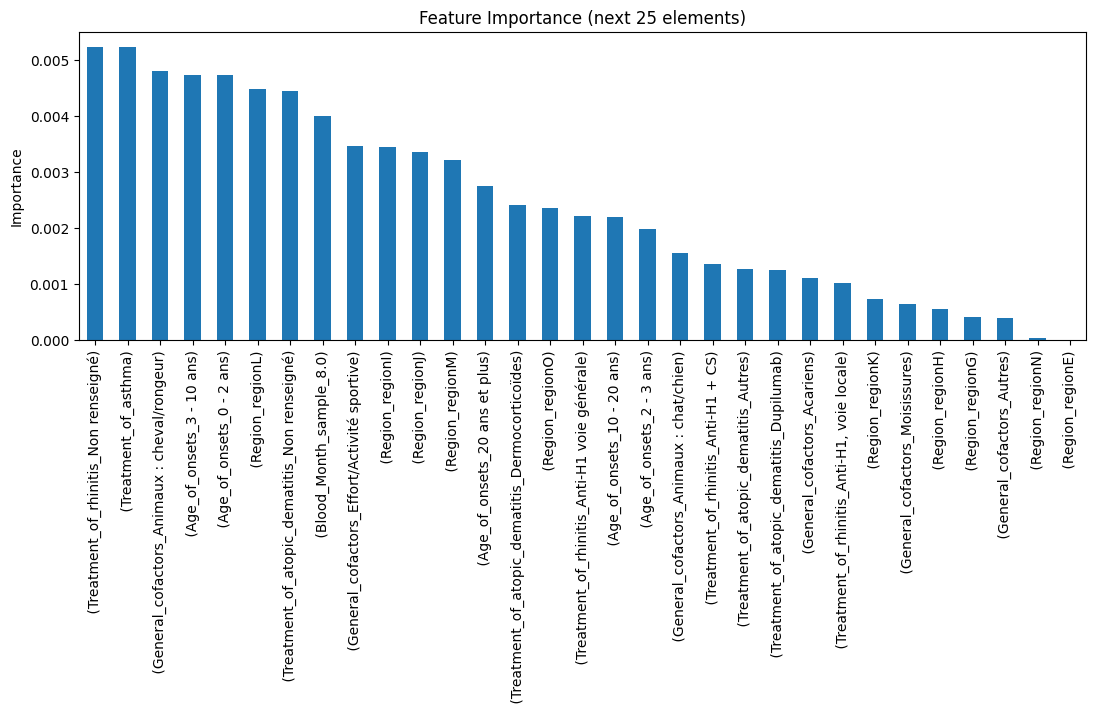

In [101]:
# Top 25 - next
importances_z = importances[50:200]

# Plot
plt.figure(figsize=(13, 4))
importances_z.plot(kind='bar')
plt.title("Feature Importance (next 25 elements)")
plt.ylabel("Importance")
plt.show()

In [71]:
len(importances)

82